**Running on Colab?** Just run the setup cell below. It clones the repo and installs the package. For a free GPU: Runtime → Change runtime type → GPU.

In [ ]:
# Colab setup
import os, sys, subprocess
from pathlib import Path

if "google.colab" in sys.modules:
    repo_root = Path("/content/SRL")
    tutorial_dir = repo_root / "tutorials_new"
    if not (repo_root / "pyproject.toml").is_file():
        subprocess.run([
            "git", "clone", "--depth=1",
            "https://github.com/StructuralRL/SRL.git", str(repo_root),
        ], check=True)
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "--no-deps", "-e", str(repo_root),
    ], check=True)
    # Make the editable install visible in this already-running kernel.
    for path in (repo_root, tutorial_dir):
        resolved = str(path.resolve())
        if resolved not in sys.path:
            sys.path.insert(0, resolved)
    os.chdir(tutorial_dir)

# 6 — Huggett with Epstein-Zin preferences

Notebook 5 solved the Huggett economy with aggregate risk and CRRA utility.
Here we keep the economy and change preferences. Epstein-Zin (EZ) utility lets
us choose risk aversion and the elasticity of intertemporal substitution
separately.

The budget constraint, saving policy, and market-clearing calculation stay the
same. The new part is the value of a simulated consumption path. Under CRRA we
add discounted flow utility moving forward through time. Under EZ we save the
path, then evaluate it with a backward recursion. SPG can differentiate that
recursion just as it differentiated the CRRA sum.

## What you should already know

- Notebook 5, especially in-loop market clearing and the policy
  $c(b,y,q,z)$.
- Notebook 2: SPG differentiates lifetime utility with respect to the policy.
- Basic CRRA preferences.

## The model: same economy, new preferences

Let $\gamma$ denote relative risk aversion and $\psi$ the intertemporal
elasticity of substitution (EIS). Risk aversion governs how the household
values consumption across uncertain states. The EIS governs how willing it is
to move consumption across dates. CRRA imposes $\psi=1/\gamma$, so changing
$\gamma$ changes both. EZ preferences let us hold $\psi$ fixed while changing
$\gamma$. That is the experiment below.

Define
$$
\rho = \frac{1}{\psi},
\qquad
\theta = \frac{1-\gamma}{1-\rho}.
$$
Epstein-Zin utility satisfies
$$
U_t = \left[(1-\beta)c_t^{1-\rho}
+ \beta\left(\mathbb E_t U_{t+1}^{1-\gamma}\right)^{
(1-\rho)/(1-\gamma)}\right]^{1/(1-\rho)}.
$$
For the code it helps to work with $\widetilde U_t=U_t^{1-\gamma}$:
$$
\widetilde U_t = \left[(1-\beta)c_t^{1-\rho}
+ \beta\left(\mathbb E_t\widetilde U_{t+1}\right)^{1/\theta}
\right]^\theta.
$$
We compute this recursion in logs so the powers remain well behaved. The
expectation is over next period's individual state, using the same sparse
household transition as in Tutorial 05.

When $\rho=\gamma$, we have $\theta=1$. Define
$$
V_t=\frac{\widetilde U_t-1}{1-\gamma}.
$$
The recursion becomes
$$
V_t=(1-\beta)u_\gamma(c_t)+\beta\mathbb E_tV_{t+1},
\qquad
u_\gamma(c)=\frac{c^{1-\gamma}-1}{1-\gamma}.
$$
This is the normalized CRRA objective from the earlier notebooks. At
$\gamma=\rho$, then, the EZ value, its policy gradient, and the resulting
consumption policy must agree with the CRRA calculation. We test all three,
including the same thick-solid versus thin-dashed policy overlay used in
Tutorials 1 and 2.

We solve $\gamma=2$ first, then use that policy to initialize $\gamma=5$, and
do the same once more for $\gamma=8$. This continuation in risk aversion is a
useful numerical shortcut: the solution at one value of $\gamma$ is a better
starting point for the next than the closed-form guess. The EIS stays at
$0.5$ throughout.

A unit mass of households trades a one-period bond:
$$
c_t+q_tb_{t+1}=b_t+z_ty_t,
\qquad b_{t+1}\geq\underline b.
$$
Idiosyncratic income $y_t$ and aggregate productivity $z_t$ are independent
Markov chains. Bonds are in zero net supply, so $q_t$ clears the market each
period. As in notebook 5, the household uses a consumption share
$$
c=s(b,y,q,z)\,(b+zy-\underline b).
$$
Nothing in this part of the model is new. We reuse Tutorial 05's asset and
income grids, consumption-share parameterization, in-loop market clearing,
and sparse transition over $(b',y')$. The code is repeated so this notebook
still runs by itself on Colab. Those cells are collapsed because we already
worked through them in Tutorial 05.

## Setup and calibration

We fix $\psi=0.5$, hence $\rho=2$, and solve for
$\gamma\in\{2,5,8\}$. The first case is the CRRA baseline. The other two raise
risk aversion without changing households' willingness to substitute across
dates.

The Huggett calibration comes from Tutorial 05. We use a five-state aggregate
process and 30 candidate bond prices. The full run uses 32 aggregate paths.
It takes about three minutes on an A100; a CPU run is possible but slow.

In [1]:
from contextlib import redirect_stderr, redirect_stdout
from functools import partial
from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.scipy.special import logsumexp

from srl import SPGSolver
from srl.utils.discretize import discrete_assets, discrete_log_ar1
from srl.utils.safe_linalg import (
    apply_A_T,
    crra_util_func,
    find_clearing_point,
    interp_two_point_nonuniform,
)

jax.config.update("jax_enable_x64", True)

print("JAX devices:", jax.devices())
if not any(device.platform == "gpu" for device in jax.devices()):
    print("No GPU detected. The full three-policy run will be slow on CPU.")

COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

JAX devices: [CudaDevice(id=0)]


In [2]:
nb, ny, nq, nz = 200, 3, 30, 5                     # grid sizes
borrowing_limit, bond_supply = -1.0, 0.0            # same as Tutorial 05
consumption_floor, beta = 0.001, 0.96
eis, risk_aversions = 0.5, (2.0, 5.0, 8.0)
rho, n_paths = 1.0 / eis, 32

b_grid = discrete_assets(0, 50 - borrowing_limit, nb) + borrowing_limit
y_grid, y_trans = discrete_log_ar1(0.6, 0.2, ny)    # idiosyncratic income
z_grid, z_trans = discrete_log_ar1(0.9, 0.02, nz)   # aggregate productivity
q_grid = jnp.linspace(0.95, 0.999, nq)               # candidate bond prices

J = nb * ny
b_dist = jnp.repeat(b_grid, ny)
y_dist = jnp.tile(y_grid, nb)
state_indices = jnp.arange(J, dtype=jnp.int32)
y_indices = state_indices % ny

print(f"household states: {J} = {nb} assets × {ny} income states")
print(f"aggregate states: {z_grid.round(4)}")
print(f"price grid: [{float(q_grid[0]):.3f}, {float(q_grid[-1]):.3f}]")

household states: 600 = 200 assets × 3 income states
aggregate states: [0.9418 0.9704 1.     1.0305 1.0618]
price grid: [0.950, 0.999]


In [3]:
# @title Tutorial 05 setup: policy parameterization (expand to inspect)
def from_diff_to_cshare(policy):
    """Reconstruct s(b, y, q, z) from its first price column and differences."""
    cpolicy = jnp.zeros((nb, ny, nq, nz))
    cpolicy = cpolicy.at[..., 0, :].set(policy["first_col"])
    cpolicy = cpolicy.at[..., 1:, :].set(policy["diff_col"])
    return jnp.cumsum(cpolicy, axis=2)


def out_of_bounds_penalty(cpolicy):
    """Return a non-positive penalty for shares outside [0, 1]."""
    return (
        jnp.minimum(cpolicy, 1e-6)
        - jnp.maximum(cpolicy - 1.0, -1e-6)
        - 2e-6
    ).mean()


def wealth_monotonicity_penalty(cpolicy):
    """Return a non-positive penalty when the share falls with assets."""
    return jnp.minimum(cpolicy[1:] - cpolicy[:-1], 0.0).mean()


def initial_consumption_share():
    b = b_grid[:, None, None, None]
    y = y_grid[None, :, None, None]
    q = q_grid[None, None, :, None]
    z = z_grid[None, None, None, :]
    wealth = b + y * z - borrowing_limit
    gross_return = 1.0 / q
    numerator = jnp.maximum(
        (gross_return - (beta * gross_return) ** (1.0 / rho))
        * (wealth + 1.0 / (gross_return - 1.0)),
        0.0,
    )
    return jnp.clip(numerator / wealth, 0.001, 1.0)


init_cshare = initial_consumption_share()
initial_policy = {
    "first_col": init_cshare[..., 0, :],
    "diff_col": jnp.diff(init_cshare, axis=2),
}

state_space = {
    "b": ("markov", nb),
    "y": ("markov", ny),
    "q": ("non-markov", nq),
    "z": ("non-markov", nz),
}
action_space = {
    "first_col": (0.001, 1.0, 0.5),
    "diff_col": (-0.2, 0.2, 0.0),
}

The next cell is Tutorial 05's one-period economy: compute bond demand over
the price grid, find the clearing price, apply the budget constraint, and
build the household transition. We make only one change. It returns
consumption rather than flow utility because the EZ recursion needs the
consumption path itself.

In [4]:
# @title Tutorial 05 setup: household transition and market clearing (expand to inspect)
def EZ_AUS_func(policy, mt, z_idx, key):
    """Return the sparse transition and consumption at aggregate state z_idx."""
    del key
    cpolicy = from_diff_to_cshare(policy)
    zt = z_grid[z_idx]
    wealth = b_dist + zt * y_dist

    # Market clearing sees the population policy but not its derivative.
    share_by_q = jax.lax.stop_gradient(cpolicy)[..., z_idx].reshape(J, nq).T
    consumption_by_q = jnp.clip(
        (wealth[None, :] - borrowing_limit) * share_by_q,
        consumption_floor,
        wealth[None, :] - (borrowing_limit + consumption_floor) * q_grid[:, None],
    )
    bond_demand = jnp.sum(
        ((wealth[None, :] - consumption_by_q) / q_grid[:, None]) * mt[None, :],
        axis=1,
    )
    q_lo, q_hi, w_lo, w_hi = find_clearing_point(bond_supply, bond_demand)
    q = q_grid[q_lo] * w_lo + q_grid[q_hi] * w_hi

    share = (
        cpolicy[:, :, q_lo, z_idx] * w_lo
        + cpolicy[:, :, q_hi, z_idx] * w_hi
    ).reshape(J)
    consumption = jnp.clip(
        (wealth - borrowing_limit) * share,
        consumption_floor,
        wealth - (borrowing_limit + consumption_floor) * q,
    )
    b_next = (wealth - consumption) / q
    b_lo, b_hi, b_w_lo, b_w_hi = interp_two_point_nonuniform(b_next, b_grid)

    income_weights = y_trans[y_indices]
    next_income = jnp.arange(ny, dtype=jnp.int32)[None, :]
    cols_lo = b_lo[:, None] * ny + next_income
    cols_hi = b_hi[:, None] * ny + next_income
    weights_lo = b_w_lo[:, None] * income_weights
    weights_hi = b_w_hi[:, None] * income_weights

    rows = jnp.broadcast_to(state_indices[:, None], (J, 2 * ny))
    columns = jnp.concatenate([cols_lo, cols_hi], axis=1)
    weights = jnp.concatenate([weights_lo, weights_hi], axis=1)
    return (rows, columns, weights), consumption, z_idx


def reset_func(key):
    """The EZ solver samples complete z paths, so this is only an API adapter."""
    return jax.random.choice(key, nz)

## From a simulated path to EZ utility

`SPGSolver` normally adds up flow utility as it moves forward through time.
EZ utility is recursive, so we do the calculation in two passes. The forward
pass simulates the aggregate shock and saves consumption together with the
household transition at every date. The backward pass starts at the end of
the path. At each date it first takes the conditional expectation over
$(b',y')$, then applies the EZ aggregator. This is the only new step in the
notebook.

The transition is sparse: from a given $(b,y)$, next-period assets lie between
two grid points and income can take `ny` values. `columns` identifies those
possible next states and `weights` gives their probabilities. JAX's
`logsumexp` computes the conditional expectation in logs without constructing
a full $J\times J$ matrix. The second function is the EZ recursion above,
written so JAX can differentiate it.

There is one numerical choice to spell out. The code draws complete $z$ paths
in the forward pass. Conditional on a path, the backward recursion integrates
over $(b',y')$ and uses the path's realized $z_{t+1}$. It then averages the
date-zero values across paths. A fully Markov implementation would instead
put $z$ in the household transition and average over $z'$ at every backward
step. Linearity makes the two calculations agree under CRRA. Away from CRRA
they need not agree exactly because the expectation sits inside the nonlinear
EZ aggregator. We keep path sampling because it preserves Tutorial 05's SPG
design. On this calibration, the equilibrium bond prices differ by less than
$10^{-3}$ from the fully Markov version. This is a choice about where to take
an expectation in the numerical implementation. It does not restrict SRL's
ability to use EZ preferences.

In [5]:
def log_sparse_expectation(log_values, columns, weights):
    """Log expected continuation value for each current household state."""
    return logsumexp(log_values[columns], b=weights, axis=-1)


def ez_backward_step(log_value_next, columns, weights, consumption, gamma, rho, theta):
    """One step of the log EZ recursion."""
    # E_t[U_{t+1}^{1-gamma}], using the sparse (b', y') transition.
    log_expected_value = log_sparse_expectation(log_value_next, columns, weights)

    def exact_nest():
        # rho = gamma: the recursion collapses to additive CRRA.
        return jnp.logaddexp(
            jnp.log1p(-beta) + (1.0 - gamma) * jnp.log(consumption),
            jnp.log(beta) + log_expected_value,
        )

    def general_ez():
        # Otherwise risk aversion and intertemporal substitution enter separately.
        inside = (
            (1.0 - beta) * consumption ** (1.0 - rho)
            + beta * jnp.exp(log_expected_value / theta)
        )
        return theta * jnp.log(jnp.maximum(inside, 1e-30))

    return jax.lax.cond(jnp.abs(theta - 1.0) < 1e-12, exact_nest, general_ez)

In [6]:
# @title Path simulation and solver adapter (expand to inspect)
class EZSPGSolver(SPGSolver):
    """SPG with a path-sampled Epstein-Zin objective."""

    def __init__(self, *, risk_aversion, eis, monotonicity_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.risk_aversion = float(risk_aversion)
        self.eis = float(eis)
        self.rho = 1.0 / self.eis
        self.theta = (1.0 - self.risk_aversion) / (1.0 - self.rho)
        self.monotonicity_weight = float(monotonicity_weight)

    def _sample_z_paths(self, key):
        """Draw one aggregate Markov path for each simulated economy."""
        def one_path(path_key):
            key_initial, key_scan = jax.random.split(path_key)
            z_initial = jax.random.choice(key_initial, nz)

            def step(carry, _):
                z_previous, key_in = carry
                key_out, key_draw = jax.random.split(key_in)
                z_next = jax.random.choice(key_draw, nz, p=z_trans[z_previous])
                return (z_next, key_out), z_next

            (_, _), z_rest = jax.lax.scan(
                step, (z_initial, key_scan), None, length=int(self.trunc_len) - 1
            )
            return jnp.concatenate([z_initial[None], z_rest])

        return jax.vmap(one_path)(jax.random.split(key, self.sample_size))

    def _forward_paths(self, policy, key, initial_distributions):
        """Store transition weights and consumption along every aggregate path."""
        z_paths = self._sample_z_paths(key)

        def one_path(path_key, initial_distribution, z_path):
            def step(mt, z_idx):
                detached_mt = jax.lax.stop_gradient(mt)
                detached_mt = detached_mt / jnp.maximum(detached_mt.sum(), 1e-12)
                A, consumption, _ = self.env_AUS_fn(
                    policy, detached_mt, z_idx, path_key
                )
                mt_next = apply_A_T(A, mt)
                _, columns, weights = A
                return mt_next, (columns, weights, consumption)

            return jax.lax.scan(step, initial_distribution, z_path)

        keys = jax.random.split(key, self.sample_size)
        return jax.vmap(one_path)(keys, initial_distributions, z_paths)

    def _ez_value(self, outputs):
        """Evaluate the unpenalized EZ objective by backward recursion."""
        columns, weights, consumption = outputs

        def backward(log_power_next, inputs):
            step_columns, step_weights, step_consumption = inputs
            value = ez_backward_step(
                log_power_next,
                step_columns,
                step_weights,
                step_consumption,
                self.risk_aversion,
                self.rho,
                self.theta,
            )
            return value, None

        def value_one_path(path_inputs):
            path_columns, path_weights, path_consumption = path_inputs
            root_log_power, _ = jax.lax.scan(
                backward,
                jnp.zeros(J),
                (path_columns, path_weights, path_consumption),
                reverse=True,
            )
            return jnp.expm1(root_log_power) / (1.0 - self.risk_aversion)

        root_values = jax.vmap(value_one_path)((columns, weights, consumption))
        initial_distribution = jnp.ones(J) / J
        return jnp.mean(root_values @ initial_distribution)

    def _policy_penalty(self, policy):
        cpolicy = from_diff_to_cshare(policy)
        return (
            out_of_bounds_penalty(cpolicy)
            + self.monotonicity_weight * wealth_monotonicity_penalty(cpolicy)
        )

    @partial(jax.jit, static_argnums=(0,))
    def _neg_simulated_utility(self, policy, key, initial_distributions):
        final_distributions, outputs = self._forward_paths(
            policy, key, initial_distributions
        )
        objective = self._ez_value(outputs) + self._policy_penalty(policy)
        return -objective, final_distributions


def crra_path_value(outputs, risk_aversion):
    """Evaluate normalized additive CRRA utility on stored path transitions."""
    columns, weights, consumption = outputs
    rows = jnp.broadcast_to(state_indices[None, None, :, None], columns.shape)

    def one_path(path_inputs):
        path_rows, path_columns, path_weights, path_consumption = path_inputs

        def step(carry, inputs):
            distribution, discount = carry
            step_rows, step_columns, step_weights, step_consumption = inputs
            flow = discount * (1.0 - beta) * jnp.sum(
                crra_util_func(step_consumption, risk_aversion) * distribution
            )
            A = (step_rows, step_columns, step_weights)
            return (apply_A_T(A, distribution), discount * beta), flow

        initial = (jnp.ones(J) / J, jnp.array(1.0))
        _, flows = jax.lax.scan(
            step,
            initial,
            (path_rows, path_columns, path_weights, path_consumption),
        )
        return flows.sum()

    return jnp.mean(jax.vmap(one_path)((rows, columns, weights, consumption)))


class CRRAPathSolver(EZSPGSolver):
    """The same path solver with the additive CRRA objective."""

    def _ez_value(self, outputs):
        return crra_path_value(outputs, self.risk_aversion)


solver_settings = dict(
    sample_size=n_paths,
    epoch=1000,
    warm_up=0,
    eps=2e-5,
    learning_rate=1e-3,
    lr_decay=0.1,
    early_stop=False,
    seed=0,
    verbose=False,
)


def solve_quietly(solver, policy_guess):
    """Run one policy solve without printing the per-iteration progress bar."""
    progress_output = StringIO()
    with redirect_stdout(progress_output), redirect_stderr(progress_output):
        return solver.solve(
            float(beta),
            state_space,
            action_space,
            EZ_AUS_func,
            reset_func,
            policy=policy_guess,
        )


def supply_and_clearing(result, z_idx):
    """Return aggregate bond demand and the interpolated clearing price."""
    cpolicy = result["cpolicy"]
    mt = result["solver"].m0.mean(axis=0)
    zt = z_grid[z_idx]
    wealth = b_dist + zt * y_dist
    share_by_q = cpolicy[..., z_idx].reshape(J, nq).T
    consumption_by_q = jnp.clip(
        (wealth[None, :] - borrowing_limit) * share_by_q,
        consumption_floor,
        wealth[None, :] - (borrowing_limit + consumption_floor) * q_grid[:, None],
    )
    demand = jnp.sum(
        ((wealth[None, :] - consumption_by_q) / q_grid[:, None]) * mt[None, :],
        axis=1,
    )
    q_lo, q_hi, w_lo, w_hi = find_clearing_point(bond_supply, demand)
    q_star = q_grid[q_lo] * w_lo + q_grid[q_hi] * w_hi
    residual = w_lo * demand[q_lo] + w_hi * demand[q_hi] - bond_supply
    return demand, float(q_star), float(residual)


def consumption_at_price(result, q, z_idx, y_idx):
    """Read one consumption policy from the price grid by interpolation."""
    q_lo, q_hi, w_lo, w_hi = interp_two_point_nonuniform(q, q_grid)
    share = (
        result["cpolicy"][:, y_idx, q_lo, z_idx] * w_lo
        + result["cpolicy"][:, y_idx, q_hi, z_idx] * w_hi
    )
    wealth = b_grid + z_grid[z_idx] * y_grid[y_idx]
    return jnp.clip(
        (wealth - borrowing_limit) * share,
        consumption_floor,
        wealth - (borrowing_limit + consumption_floor) * q,
    )

## Check the CRRA case

Just like in notebooks 1 and 2, it's most instructive when we can start from
and replicate a benchmark that we already solved. Here this is simple. When
$\gamma=\rho=2$, EZ simplifies to additive CRRA. We show this numerically now.

The code below starts with that case, then carries its policy forward to
$\gamma=5$ and $\gamma=8$. We use 1,000 updates and 32 aggregate paths for
each solve.

In [7]:
results = {}
policy_guess = initial_policy

# Continuation in gamma: each solution initializes the next one.
for risk_aversion in risk_aversions:
    theta = (1.0 - risk_aversion) / (1.0 - 1.0 / eis)
    print(f"training gamma={risk_aversion:.0f}, theta={theta:.0f}")

    solver = EZSPGSolver(
        risk_aversion=risk_aversion,
        eis=eis,
        monotonicity_weight=1.0,
        **solver_settings,
    )
    policy, logs = solve_quietly(solver, policy_guess)

    # Keep the policy, reconstructed share, and diagnostics for the figures.
    results[risk_aversion] = {
        "solver": solver,
        "policy": policy,
        "cpolicy": from_diff_to_cshare(policy),
        "logs": logs,
    }
    policy_guess = jax.tree.map(lambda value: value.copy(), policy)
    print(
        f"  objective={logs[-1]['cumulative_utility']:.6f}, "
        f"time={solver.total_time:.1f}s"
    )

training gamma=2, theta=1


  objective=0.148171, time=59.2s
training gamma=5, theta=4


  objective=0.073190, time=58.8s
training gamma=8, theta=7


  objective=0.033356, time=61.8s


We check the CRRA benchmark in two ways.

First, we evaluate one policy on the same simulated paths with the EZ backward
recursion and with the CRRA sum. Both the value and its policy gradient should
agree up to floating-point error. Second, we train a separate additive-CRRA
solver from the same initial policy. The resulting consumption policy should
sit on top of the $\gamma=2$ EZ policy.

In [8]:
# Same paths and optimizer as the exact-nest solve; only the objective changes.
crra_solver = CRRAPathSolver(
    risk_aversion=2.0,
    eis=0.5,
    monotonicity_weight=1.0,
    **solver_settings,
)
crra_policy, crra_logs = solve_quietly(crra_solver, initial_policy)
crra_result = {
    "solver": crra_solver,
    "policy": crra_policy,
    "cpolicy": from_diff_to_cshare(crra_policy),
    "logs": crra_logs,
}
print(f"CRRA baseline: {crra_solver.total_time:.1f}s, "
      f"objective={crra_logs[-1]['cumulative_utility']:.6f}")

CRRA baseline: 69.6s, objective=0.148175


In [9]:
# @title Exact-nest diagnostic (expand to inspect)
exact = results[2.0]
exact_solver = exact["solver"]
check_key = jax.random.PRNGKey(2026)


def ez_check_objective(policy):
    _, outputs = exact_solver._forward_paths(policy, check_key, exact_solver.m0)
    return exact_solver._ez_value(outputs)


def crra_check_objective(policy):
    _, outputs = exact_solver._forward_paths(policy, check_key, exact_solver.m0)
    return crra_path_value(outputs, 2.0)


ez_objective, ez_gradient = jax.value_and_grad(ez_check_objective)(exact["policy"])
crra_objective, crra_gradient = jax.value_and_grad(crra_check_objective)(
    exact["policy"]
)
gradient_gap = jnp.sqrt(
    sum(
        jnp.sum((ez_leaf - crra_leaf) ** 2)
        for ez_leaf, crra_leaf in zip(
            jax.tree_util.tree_leaves(ez_gradient),
            jax.tree_util.tree_leaves(crra_gradient),
        )
    )
)
gradient_norm = jnp.sqrt(
    sum(jnp.sum(leaf**2) for leaf in jax.tree_util.tree_leaves(crra_gradient))
)

print(f"EZ objective:   {float(ez_objective): .12f}")
print(f"CRRA objective: {float(crra_objective): .12f}")
print(f"absolute gap:   {float(jnp.abs(ez_objective - crra_objective)):.3e}")
print(f"relative gradient gap: {float(gradient_gap / gradient_norm):.3e}")

price_by_gamma = {
    risk_aversion: jnp.array(
        [supply_and_clearing(results[risk_aversion], z_idx)[1] for z_idx in range(nz)]
    )
    for risk_aversion in risk_aversions
}

EZ objective:    0.152322505109
CRRA objective:  0.152322505109
absolute gap:   2.776e-17
relative gradient gap: 9.238e-13


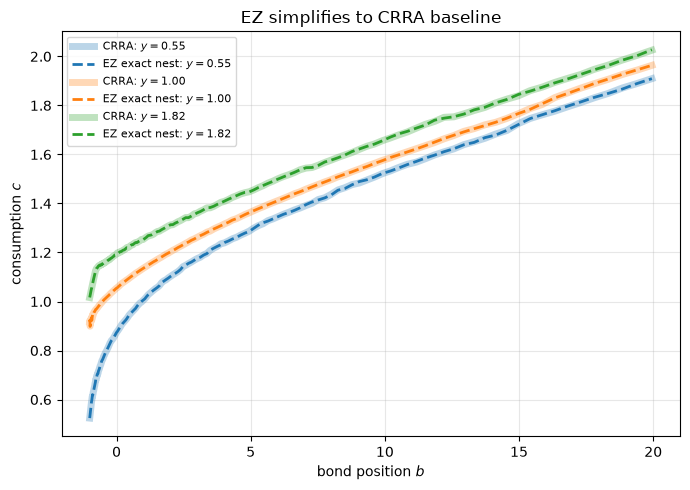

max |c_EZ - c_CRRA| for b <= 20: 8.366e-03
equilibrium prices: EZ 0.976582, CRRA 0.976579, absolute gap 3.35e-06


In [10]:
z_idx = nz // 2
on_support = b_grid <= 20
q_ez = supply_and_clearing(exact, z_idx)[1]
q_crra = supply_and_clearing(crra_result, z_idx)[1]

fig, ax = plt.subplots(figsize=(7, 5))
max_abs = 0.0
for y_idx in range(ny):
    # Each independently trained policy is evaluated at its own clearing price.
    c_crra = consumption_at_price(crra_result, q_crra, z_idx, y_idx)
    c_ez = consumption_at_price(exact, q_ez, z_idx, y_idx)
    max_abs = max(max_abs, float(jnp.max(jnp.abs(c_ez - c_crra)[on_support])))

    # Same visual check as Tutorials 1 and 2: thick baseline, dashed new method.
    line, = ax.plot(
        b_grid[on_support], c_crra[on_support], lw=5, alpha=0.3,
        label=rf"CRRA: $y={float(y_grid[y_idx]):.2f}$",
    )
    ax.plot(
        b_grid[on_support], c_ez[on_support], lw=2, ls="--",
        color=line.get_color(),
        label=rf"EZ exact nest: $y={float(y_grid[y_idx]):.2f}$",
    )

ax.set_xlabel("bond position $b$")
ax.set_ylabel("consumption $c$")
ax.set_title("EZ simplifies to CRRA baseline")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print(f"max |c_EZ - c_CRRA| for b <= 20: {max_abs:.3e}")
print(f"equilibrium prices: EZ {q_ez:.6f}, CRRA {q_crra:.6f}, "
      f"absolute gap {abs(q_ez - q_crra):.2e}")

The thick CRRA lines and dashed EZ lines nearly sit on top of each other, as in
the policy checks in Tutorials 1 and 2. The maximum consumption gap is about
$0.007$ on the plotted region and the equilibrium-price gap is below
$5\times10^{-6}$. The value and gradient agree much more tightly because they
are evaluated at one fixed policy. During training, tiny floating-point
differences accumulate over 1,000 stochastic updates. The policy comparison
is the economically relevant check, and it passes at the same scale as the
earlier SPG comparisons.

## What changes when risk aversion rises?

We can now vary $\gamma$ while the EIS stays at $0.5$. The first figure plots
consumption for the middle income and aggregate states. Each line uses its
own equilibrium bond price. The policies are close at low wealth and separate
farther up the asset grid.

Read this as a general-equilibrium comparison. A change in $\gamma$ moves the
household policy, the wealth distribution, and the clearing price together.
The vertical distance between two lines therefore is not a
partial-equilibrium measure of precautionary saving. To isolate that channel,
we would hold the price and distribution fixed.

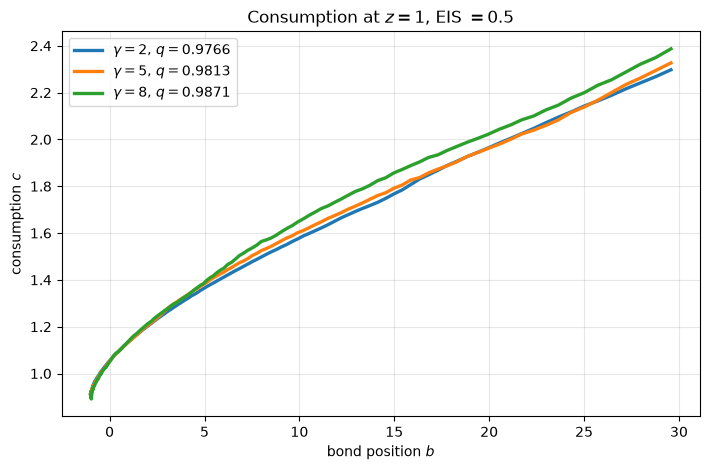

In [11]:
z_idx = nz // 2
y_idx = ny // 2
b_mask = jnp.where(b_grid <= 30)[0]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for color, risk_aversion in zip(COLORS, risk_aversions):
    result = results[risk_aversion]
    q_star = price_by_gamma[risk_aversion][z_idx]
    # Reuse the same price-grid interpolation as the CRRA check.
    consumption = consumption_at_price(result, q_star, z_idx, y_idx)
    ax.plot(
        b_grid[b_mask],
        consumption[b_mask],
        color=color,
        linewidth=2.4,
        label=rf"$\gamma={risk_aversion:.0f}$, $q={q_star:.4f}$",
    )

ax.set_xlabel("bond position $b$")
ax.set_ylabel("consumption $c$")
ax.set_title(r"Consumption at $z=1$, EIS $=0.5$")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

The equilibrium price rises with risk aversion at every aggregate state in
this calibration. Since the gross return is $1/q$, a higher bond price is a
lower equilibrium return. The price adjusts until the stronger demand for the
bond is again consistent with zero net supply. Aggregate productivity also
shifts the clearing price, which is why each line slopes upward in $z$.

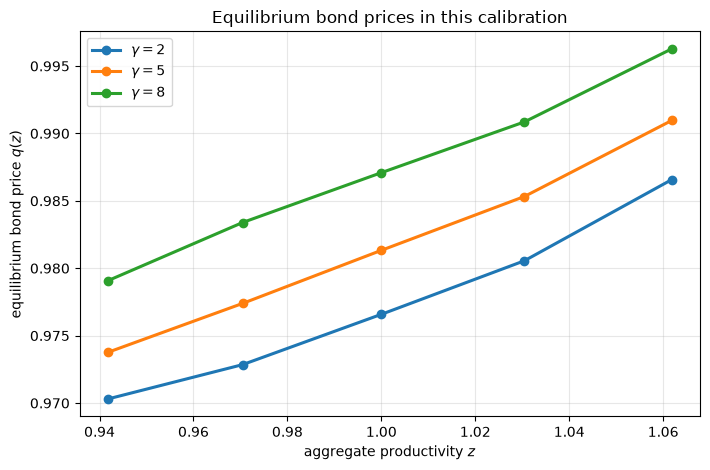

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for color, risk_aversion in zip(COLORS, risk_aversions):
    ax.plot(
        z_grid,
        price_by_gamma[risk_aversion],
        "o-",
        color=color,
        linewidth=2.2,
        label=rf"$\gamma={risk_aversion:.0f}$",
    )
ax.set_xlabel("aggregate productivity $z$")
ax.set_ylabel("equilibrium bond price $q(z)$")
ax.set_title(r"Equilibrium bond prices in this calibration")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

The optimization traces are a numerical diagnostic, not another comparative
static. Utility levels are not comparable across $\gamma$ because the
curvature and normalization change. Within each run, the objective settles
down quickly and the policy update keeps falling. The occasional spikes for
$\gamma=8$ come from the sampled aggregate paths; the downward trend is what
matters here.

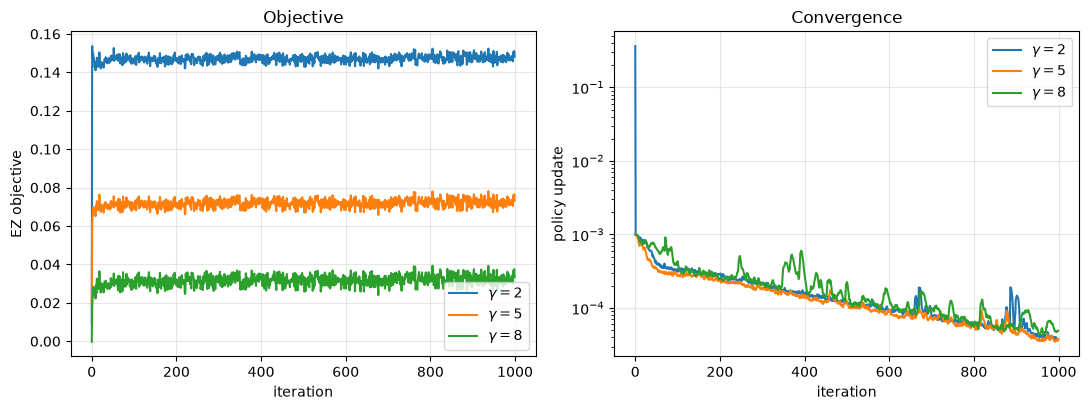

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
for color, risk_aversion in zip(COLORS, risk_aversions):
    logs = results[risk_aversion]["logs"]
    # Objective on the left; maximum policy update on the right.
    axs[0].plot(
        [entry["cumulative_utility"] for entry in logs],
        color=color,
        label=rf"$\gamma={risk_aversion:.0f}$",
    )
    axs[1].plot(
        [entry["max_l1_err"] for entry in logs],
        color=color,
        label=rf"$\gamma={risk_aversion:.0f}$",
    )
axs[0].set_xlabel("iteration")
axs[0].set_ylabel("EZ objective")
axs[0].set_title("Objective")
axs[1].set_xlabel("iteration")
axs[1].set_ylabel("policy update")
axs[1].set_yscale("log")
axs[1].set_title("Convergence")
for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Finally, we check the equilibrium calculation itself. The exact-nest test
above checks the preference recursion. Here we verify that aggregate bond
demand is zero at every reported price. The residual is computed after the
same linear interpolation used inside the environment.

In [14]:
for risk_aversion in risk_aversions:
    # Check every aggregate state, not only the state used in the figures.
    residuals = jnp.array(
        [
            abs(supply_and_clearing(results[risk_aversion], z_idx)[2])
            for z_idx in range(nz)
        ]
    )
    print(
        f"gamma={risk_aversion:.0f}: "
        f"max market-clearing residual = {float(residuals.max()):.3e}"
    )

gamma=2: max market-clearing residual = 8.674e-19
gamma=5: max market-clearing residual = 8.674e-19
gamma=8: max market-clearing residual = 8.674e-19


## Exercises

1. **Return to CRRA.** Change the EIS so that $\rho=\gamma$ for one of the
   higher-risk-aversion cases. Verify that `theta == 1` and that the EZ and
   additive CRRA objectives agree.
2. **Separate risk aversion from the EIS.** Hold $\gamma=5$ fixed and compare
   EIS values of $0.4$, $0.5$, and $0.75$. Which parts of the consumption
   policy and equilibrium price response are due to substitution across dates?
3. **Inspect market clearing.** For the middle aggregate state, plot bond
   demand against $q$ for all three values of $\gamma$. Mark the interpolated
   zero of each schedule.

### Exercise 1: return to CRRA (worked)

Set $\psi=1/\gamma$. Then $\rho=1/\psi=\gamma$ and
$\theta=(1-\gamma)/(1-\rho)=1$. The continuation term is linear, which gives
the additive recursion derived in the exact-nest section. The numerical check
above verifies both the objective and its policy gradient on the same paths.

### Exercise 2: separate risk aversion from the EIS (worked)

For $\gamma=5$, changing the EIS changes $\rho$ and therefore $\theta$.
Retraining these cases would isolate intertemporal substitution while holding
risk aversion fixed.

In [15]:
gamma_exercise = 5.0
for eis_exercise in (0.4, 0.5, 0.75):
    rho_exercise = 1.0 / eis_exercise
    theta_exercise = (1.0 - gamma_exercise) / (1.0 - rho_exercise)
    print(
        f"EIS={eis_exercise:.2f}: rho={rho_exercise:.3f}, "
        f"theta={theta_exercise:.3f}"
    )

EIS=0.40: rho=2.500, theta=2.667
EIS=0.50: rho=2.000, theta=4.000
EIS=0.75: rho=1.333, theta=12.000


### Exercise 3: inspect market clearing (worked)

The star marks the price where each bond-demand curve crosses zero.

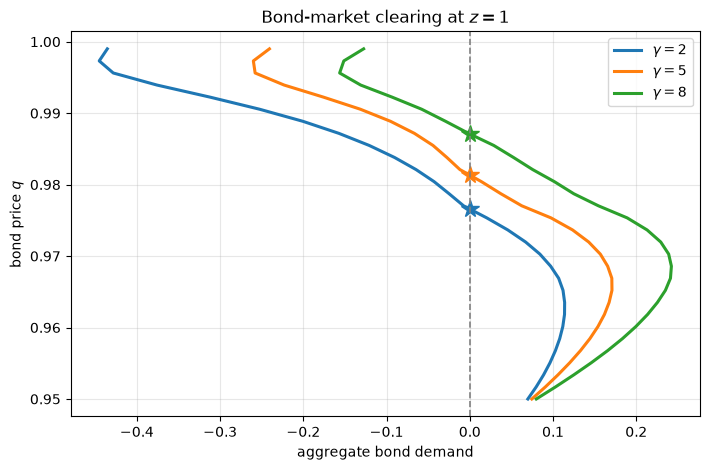

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for color, risk_aversion in zip(COLORS, risk_aversions):
    demand, q_star, _ = supply_and_clearing(results[risk_aversion], nz // 2)
    ax.plot(demand, q_grid, color=color, linewidth=2.2,
            label=rf"$\gamma={risk_aversion:.0f}$")
    ax.plot(0.0, q_star, "*", color=color, markersize=13)
ax.axvline(0.0, color="grey", linestyle="--", linewidth=1.2)
ax.set_xlabel("aggregate bond demand")
ax.set_ylabel("bond price $q$")
ax.set_title(r"Bond-market clearing at $z=1$")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()